<a href="https://colab.research.google.com/github/kishita21/MLDL/blob/main/EXP9/EXP9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

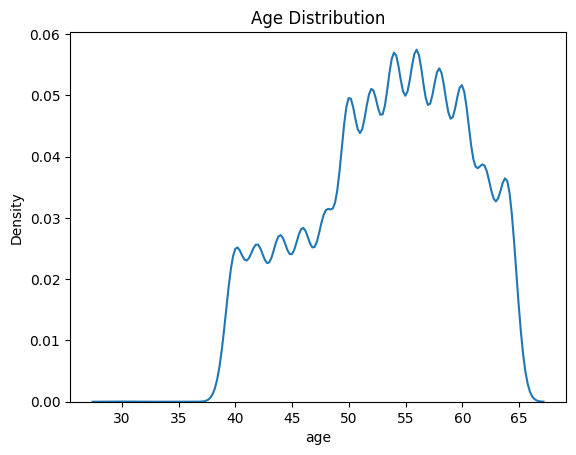

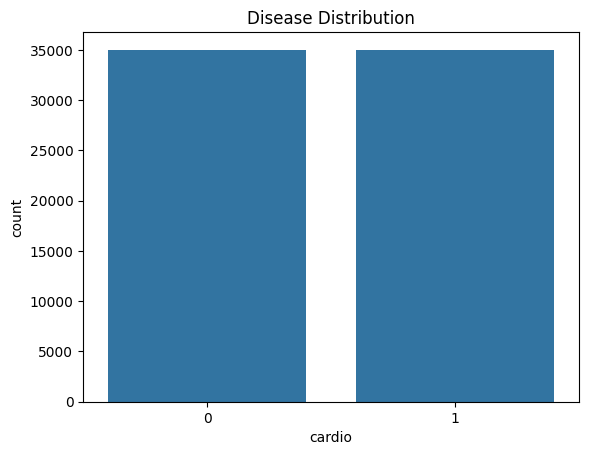

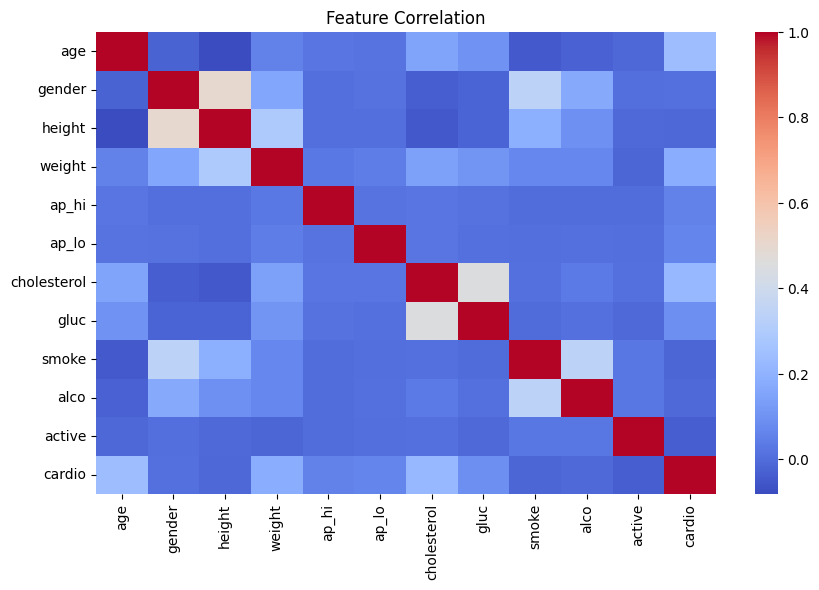

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.6317 - loss: 0.6389 - val_accuracy: 0.6504 - val_loss: 0.6269
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.6587 - loss: 0.6191 - val_accuracy: 0.6629 - val_loss: 0.6149
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.6651 - loss: 0.6120 - val_accuracy: 0.6675 - val_loss: 0.6118
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.6765 - loss: 0.6028 - val_accuracy: 0.6665 - val_loss: 0.6120
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6884 - loss: 0.5915 - val_accuracy: 0.6912 - val_loss: 0.5923
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6986 - loss: 0.5813 - val_accuracy: 0.7059 - val_loss: 0.5749
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7157 - loss: 0.5663 - val_accuracy: 0.7208 - val_loss: 0.5571
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7262 - loss: 0

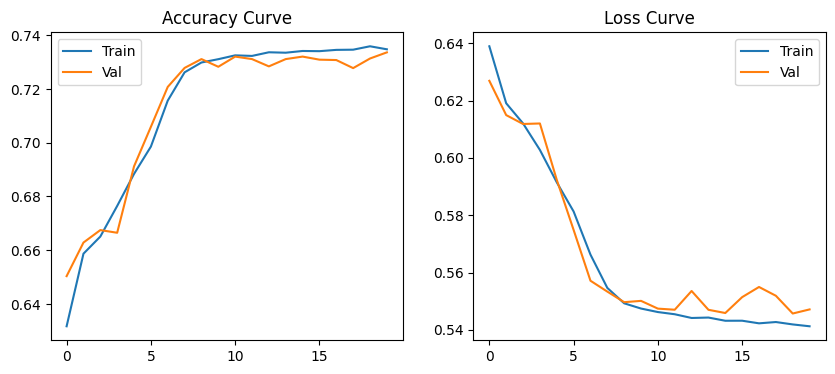

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


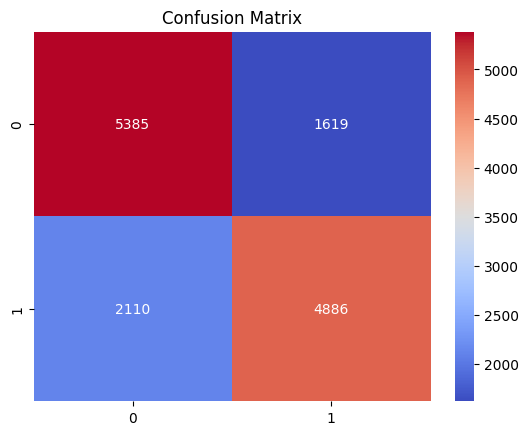

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


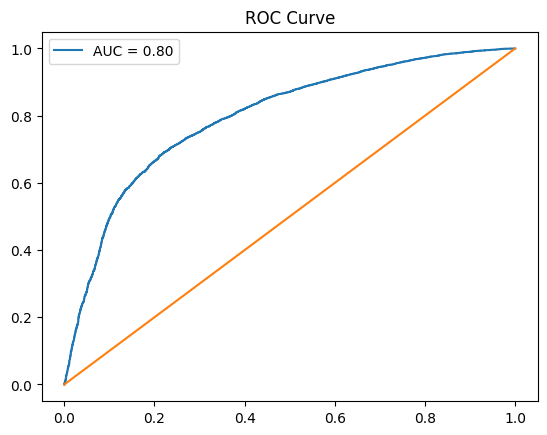

              precision    recall  f1-score   support

           0       0.72      0.77      0.74      7004
           1       0.75      0.70      0.72      6996

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000



In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv('/content/cardio_train.csv', sep=';')

# CLEAN
df = df.drop('id', axis=1)
df['age'] = df['age'] / 365

# ==============================
# 🎨 ADVANCED VISUALIZATION
# ==============================

# 1. Distribution curve
sns.kdeplot(df['age'])
plt.title("Age Distribution")
plt.show()

# 2. Target distribution
sns.countplot(x='cardio', data=df)
plt.title("Disease Distribution")
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# ==============================
# PREPROCESSING
# ==============================
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 🔥 RESHAPE FOR LSTM (KEY STEP)
# ==============================
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# ==============================
# LSTM MODEL
# ==============================
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1],1)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# ==============================
# TRAIN
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ==============================
# 📈 TRAINING VISUALS
# ==============================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss Curve")
plt.legend()

plt.show()

# ==============================
# PREDICTION
# ==============================
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

# ==============================
# ROC CURVE (🔥 IMPORTANT)
# ==============================
y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.legend()
plt.show()

# ==============================
# REPORT
# ==============================
print(classification_report(y_test, y_pred))